# Results from the ML model with GenMET_px, GenMET_py as targets

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import sys

sys.path.append("../../MET_models/")
from MET_pxpy_utils import _apply_standardize, _read_data
from MET_pxpy_testing import load_model_and_scaler

In [2]:
def _pt(px, py):
    return np.sqrt(px**2 + py**2)

In [3]:
def load_predictions(event: str):
    """
        Loads MET_pt_pred, MET_pt (reco) and GenMET_pt from the parquet
        saved by the prediction on dataset.

        Parameters:
            event      : str — dataset/event label (e.g. "DYJetsToLL")
            output_dir : str — directory where the parquet was saved

        Returns:
            Y_pred  : np.ndarray — NN-predicted MET_pt
            y_true  : np.ndarray — GenMET_pt (ground truth)
            MET_pt  : np.ndarray — reconstructed MET_pt
    """
    parquet_path = f"predictions_testing_pxpy_{event}.parquet"
    if not os.path.exists(parquet_path):
        raise FileNotFoundError(f"Parquet not found: {parquet_path}")

    df = pd.read_parquet(parquet_path)
    print(f"  Loaded {len(df):,} events from '{parquet_path}'")
    print(f"  Columns: {list(df.columns)}")

    def _get(col):
        if col in df.columns:
            return df[col].to_numpy()
        print(f"  [WARNING] Column '{col}' not found.")
        return None

    pred_px = _get("pred_MET_px");  pred_py = _get("pred_MET_py")
    true_px = _get("GenMET_px");    true_py = _get("GenMET_py")
    reco_px = _get("MET_px");       reco_py = _get("MET_py")

    pred_pt = _get("pred_MET_pt") if "pred_MET_pt" in df.columns else (
              _pt(pred_px, pred_py) if pred_px is not None else None)
    true_pt = _get("GenMET_pt")   if "GenMET_pt"   in df.columns else (
              _pt(true_px, true_py) if true_px is not None else None)
    reco_pt = _get("MET_pt")      if "MET_pt"      in df.columns else (
              _pt(reco_px, reco_py) if reco_px is not None else None)

    return (pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt)

In [4]:
def _compute_metrics(pred_px, pred_py, pred_pt,
                     true_px, true_py, true_pt,
                     reco_px, reco_py, reco_pt,
                     event: str):
    """
        Prints MSE/RMSE/MAE/R² for px, py and pt,
        both for reco vs Gen and predicted vs Gen,
        plus absolute and relative improvements.
    """
    components = [
        ("px", pred_px, true_px, reco_px),
        ("py", pred_py, true_py, reco_py),
        ("pt", pred_pt, true_pt, reco_pt),
    ]

    for comp, pred, true, reco in components:
        print(f"\n{comp.upper()} - {event}")

        rmse_reco = np.sqrt(mean_squared_error(true, reco))
        mae_reco  = mean_absolute_error(true, reco)
        r2_reco   = r2_score(true, reco)
        print(f"Reconstruction performance for {event}:")
        print(f"    RMSE = {rmse_reco:.4f} GeV")
        print(f"    MAE  = {mae_reco:.4f} GeV")
        print(f"    R²   = {r2_reco:.4f}")

        rmse_pred = np.sqrt(mean_squared_error(true, pred))
        mae_pred  = mean_absolute_error(true, pred)
        r2_pred   = r2_score(true, pred)
        print(f"ML model performance for {event}:")
        print(f"    RMSE = {rmse_pred:.4f} GeV")
        print(f"    MAE  = {mae_pred:.4f} GeV")
        print(f"    R²   = {r2_pred:.4f}")
        
        DELTA_rmse = rmse_reco - rmse_pred
        DELTA_mae  = mae_reco  - mae_pred
        DELTA_r2   = r2_pred   - r2_reco

        pct_rmse = DELTA_rmse / rmse_reco * 100
        pct_mae  = DELTA_mae  / mae_reco  * 100
        pct_r2   = DELTA_r2   / abs(r2_reco) * 100 if r2_reco != 0 else float("nan")
        print(f"Performance improvement for {event}:")
        print(f"    DELTA_RMSE = {DELTA_rmse:+.4f} GeV ({pct_rmse:+.2f}%)")
        print(f"    DELTA_MAE  = {DELTA_mae:+.4f} GeV ({pct_mae:+.2f}%)")
        print(f"    DELTA_R²   = {DELTA_r2:+.4f}     ({pct_r2:+.2f}%)")
        return

In [5]:
def _plot_fold_learning_curves(df_folds: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("CV Fold Learning Curves", fontsize=13, fontweight="bold")
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for fold_idx, df in df_folds.groupby("fold"):
        c = colors[(fold_idx - 1) % len(colors)]
        axes[0].plot(df["epoch"], df["loss"],
                     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[0].plot(df["epoch"], df["val_loss"],
                     color=c, lw=1.5, ls="--", label=f"Val fold {fold_idx}")
        axes[1].plot(df["epoch"], df["loss"].pow(0.5),
                     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[1].plot(df["epoch"], df["val_loss"].pow(0.5),
                     color=c, lw=1.5, ls="--", label=f"Val fold {fold_idx}")

    for ax, ylabel, title in zip(axes, ["MSE", "RMSE"], ["Loss (MSE)", "RMSE"]):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

In [6]:
def _plot_learning_curves(df_lc: pd.DataFrame):
    epochs  = range(1, len(df_lc) + 1)
    has_val = "val_loss" in df_lc.columns
    has_mse = "mse" in df_lc.columns

    fig, axes = plt.subplots(1, 2 if has_mse else 1,
                             figsize=(14 if has_mse else 7, 5))
    if not has_mse:
        axes = [axes]
    fig.suptitle("Learning Curves", fontsize=13, fontweight="bold")

    axes[0].plot(epochs, df_lc["loss"], color="red", lw=1.5, label="Train loss")
    if has_val:
        axes[0].plot(epochs, df_lc["val_loss"], color="blue", lw=1.5, label="Val loss")
    axes[0].set_title("Loss (MSE)"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE");       axes[0].legend(); axes[0].grid(alpha=0.3)

    if has_mse:
        axes[1].plot(epochs, df_lc["mse"].pow(0.5), color="red", lw=1.5, label="Train RMSE")
        if has_val:
            axes[1].plot(epochs, df_lc["val_mse"].pow(0.5), color="blue", lw=1.5, label="Val RMSE")
        axes[1].set_title("RMSE metric"); axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("RMSE");       axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"  Epochs run       : {len(df_lc)}")
    print(f"  Final train loss : {df_lc['loss'].iloc[-1]:.4f}")
    if has_val:
        print(f"  Final val loss   : {df_lc['val_loss'].iloc[-1]:.4f}")
        print(f"  Best  val loss   : {df_lc['val_loss'].min():.4f}  "
              f"(epoch {df_lc['val_loss'].idxmin() + 1})")
    return

In [7]:
def _scatter_one(ax, x, y, xlabel, ylabel, title, color):
    """
        Single scatter panel with identity line and annotation.
    """
    ax.scatter(x, y, alpha=0.3, s=8, color=color, rasterized=True)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "r--", lw=1.2, label="y = x")
    r2   = r2_score(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    ax.text(0.05, 0.92, f"RMSE = {rmse:.2f} GeV\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(fontsize=8)
    return

In [8]:
def _scatterplots(pred_px, pred_py, pred_pt,
                  true_px, true_py, true_pt,
                  reco_px, reco_py, reco_pt,
                  event: str):
    """
        Layout:
        - 3 rows = px / py / pt
        - 2 cols = Reco vs Gen | Predicted vs Gen
    """
    fig, axes = plt.subplots(3, 2, figsize=(13, 17))
    fig.suptitle(f"Scatter plots — {event}", fontsize=14, fontweight="bold")

    rows = [
        ("px", true_px, pred_px, reco_px, "GenMET_px [GeV]",
         "pred_MET_px [GeV]", "MET_px [GeV]", "steelblue"),
        ("py", true_py, pred_py, reco_py, "GenMET_py [GeV]",
         "pred_MET_py [GeV]", "MET_py [GeV]", "darkorange"),
        ("pt", true_pt, pred_pt, reco_pt, "GenMET_pt [GeV]",
         "pred_MET_pt [GeV]", "MET_pt [GeV]",  "seagreen"),
    ]

    for row_i, (comp, true, pred, reco,
                xlabel, ylabel_pred, ylabel_reco, color) in enumerate(rows):
        _scatter_one(axes[row_i, 0], true, reco,
                     xlabel, ylabel_reco,
                     f"Reco vs Gen — {comp}", color)
        _scatter_one(axes[row_i, 1], true, pred,
                     xlabel, ylabel_pred,
                     f"Predicted vs Gen — {comp}", color)

    plt.tight_layout()
    plt.show()
    return

In [9]:
def _response_plots(pred_px, pred_py, pred_pt,
                    true_px, true_py, true_pt,
                    reco_px, reco_py, reco_pt,
                    event: str, max_scatter_points: int = 10000):
    """
        Per component (px, py) and module (pt) response plots.

        For px e py the pred/true response can be negative;
        For pt the pred/true response is always positive (mask > 0)

        Layout:
        - 3 rows: px / py / pt
        - 2 columns: response histogram | scatter response vs Gen
    """
    components = [
        ("px", pred_px, true_px, reco_px, "GenMET_px [GeV]", 0,   None),
        ("py", pred_py, true_py, reco_py, "GenMET_py [GeV]", 0,   None),
        ("pt", pred_pt, true_pt, reco_pt, "GenMET_pt [GeV]", 0.1, (0, 4)),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Response (pred/Gen) - {event}", fontsize=14, fontweight="bold")

    for row_i, (comp, pred, true, reco, xlabel, min_true, ylim_scatter) in enumerate(components):

        # mask: avoid division by zero
        mask      = np.abs(true) > min_true
        resp_pred = pred[mask] / true[mask]
        resp_reco = reco[mask] / true[mask]
        gen_m     = true[mask]

        # subsample for scatter only
        n_total = len(gen_m)
        idx = (np.random.choice(n_total, size=max_scatter_points, replace=False)
               if n_total > max_scatter_points else np.arange(n_total))

        mu_pred, sig_pred = resp_pred.mean(), resp_pred.std()
        mu_reco, sig_reco = resp_reco.mean(), resp_reco.std()

        # Left: response histogram (all events)
        ax_hist = axes[row_i, 0]

        if comp in ("px", "py"):
            # the response can be negative: bins centered on -1
            bins = np.linspace(-3, 5, 100)
        else:
            bins = np.linspace(0, 3, 80)

        ax_hist.hist(resp_pred, bins=bins, alpha=0.6, color="darkorange",
                     label=f"Pred  (μ={mu_pred:.2e}, σ={sig_pred:.2e})")
        ax_hist.hist(resp_reco, bins=bins, alpha=0.6, color="steelblue",
                     label=f"Reco  (μ={mu_reco:.2e}, σ={sig_reco:.2e})")
        ax_hist.axvline(1, color="red", ls="--", lw=1.2, label="ideal = 1")
        ax_hist.set_xlabel(f"pred_{comp} / Gen{comp}", fontsize=11)
        ax_hist.set_ylabel("Events", fontsize=11)
        ax_hist.set_title(f"Response distribution - {comp}", fontsize=11)
        ax_hist.legend(fontsize=9)
        ax_hist.grid(alpha=0.3)

        # Right: response vs GenMET scatter (subsampled)
        ax_sc = axes[row_i, 1]

        ax_sc.scatter(gen_m[idx], resp_pred[idx], alpha=0.4, s=8,
                      color="darkorange", label=f"Pred (n={len(idx):,})", rasterized=True)
        ax_sc.scatter(gen_m[idx], resp_reco[idx], alpha=0.4, s=8,
                      color="steelblue",  label=f"Reco (n={len(idx):,})", rasterized=True)
        ax_sc.axhline(1, color="red", ls="--", lw=1.2, label="ideal = 1")
        ax_sc.set_xlabel(xlabel, fontsize=11)
        ax_sc.set_ylabel(f"pred_{comp} / Gen{comp}", fontsize=11)
        ax_sc.set_title(f"Response vs Gen{comp}", fontsize=11)
        ax_sc.legend(fontsize=9)
        ax_sc.grid(alpha=0.3)
        if ylim_scatter is not None:
            ax_sc.set_ylim(ylim_scatter)

    plt.tight_layout()
    plt.show()
    return

In [10]:
def _profile_histogram_response(pred_px, pred_py, pred_pt,
                                true_px, true_py, true_pt,
                                reco_px, reco_py, reco_pt,
                                event: str,
                                bin_width: float = 10.0,
                                min_counts: int = 10,
                                min_Gen: float = 50.0):
    """
        Profile histogram of the response (MET / GenMET) vs GenMET for px, py, pt.

        Layout:
        - 3 rows: px / py / pt
        - 2 cols: mean response / std resolution

        Parameters:
            pred_px/py/pt : np.ndarray — NN-predicted components
            true_px/py/pt : np.ndarray — Gen-level components (ground truth)
            reco_px/py/pt : np.ndarray — reconstructed components
            event         : str        — dataset/event label for title
            bin_width     : float      — bin width in GeV for all components (default 10 GeV)
            min_counts    : int        — minimum events per bin to plot (default 10)
            min_Gen       : float      — minimum GenMET_pt to avoid near-zero division for pt (default 1 GeV)
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Response Profile Histogram - {event}",
                 fontsize=14, fontweight="bold")

    components = [
        ("px", true_px, pred_px, reco_px, None),       # min_gen=None → no masking
        ("py", true_py, pred_py, reco_py, None),
        ("pt", true_pt, pred_pt, reco_pt, min_Gen),    # min_Gen applied only to pt
    ]

    for row_i, (comp, true, pred, reco, mg) in enumerate(components):

        # apply min_gen mask only for pt
        if mg is not None:
            mask     = true > mg
            true_m   = true[mask]
            pred_m   = pred[mask]
            reco_m   = reco[mask]
            print(f"  [{comp}] Excluding Gen{comp} <= {mg} GeV "
                  f"({(~mask).sum():,} events removed)")
        else:
            true_m = true
            pred_m = pred
            reco_m = reco

        x_max  = np.ceil(true_m.max()  / bin_width) * bin_width
        x_min  = np.floor(true_m.min() / bin_width) * bin_width
        n_bins = int(round((x_max - x_min) / bin_width))
        bins        = np.linspace(x_min, x_max, n_bins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_indices = np.clip(np.digitize(true_m, bins) - 1, 0, n_bins - 1)
        counts_true = np.array([(bin_indices == i).sum() for i in range(n_bins)])

        valid_mask      = counts_true >= min_counts
        first_valid_bin = np.min(np.where(valid_mask)[0])
        last_valid_bin  = np.max(np.where(valid_mask)[0])
        x_plot_min      = bins[first_valid_bin]
        x_plot_max      = bins[last_valid_bin + 1]

        print(f"  [{comp}] bin_width={bin_width} GeV | "
              f"range [{x_plot_min:.0f}, {x_plot_max:.0f}] GeV | "
              f"n_bins={n_bins}")

        arrays  = {f"pred {comp}": pred_m, f"reco {comp}": reco_m}
        colors  = {f"pred {comp}": "darkorange", f"reco {comp}": "steelblue"}
        markers = {f"pred {comp}": "o",           f"reco {comp}": "^"}

        for label, arr in arrays.items():
            response = np.where(true_m != 0, arr / true_m, np.nan)
            means  = np.full(n_bins, np.nan)
            stds   = np.full(n_bins, np.nan)
            counts = np.zeros(n_bins, dtype=int)

            for i in range(n_bins):
                mask_i    = (bin_indices == i)
                counts[i] = mask_i.sum()
                if counts[i] >= min_counts:
                    means[i] = np.nanmean(response[mask_i])
                    stds[i]  = np.nanstd(response[mask_i])

            valid = (counts >= min_counts) & (bin_centers >= x_plot_min) & (bin_centers <= x_plot_max)

            axes[row_i, 0].errorbar(
                bin_centers[valid], means[valid], yerr=stds[valid],
                fmt="none", ecolor=colors[label], elinewidth=1.2,
                capsize=4, capthick=1.2)
            axes[row_i, 0].plot(
                bin_centers[valid], means[valid],
                marker=markers[label], color=colors[label],
                label=label, markersize=5, linewidth=1.2, linestyle="-")
            axes[row_i, 1].plot(
                bin_centers[valid], stds[valid],
                marker=markers[label], color=colors[label],
                label=label, markersize=5, linewidth=1.2)

        axes[row_i, 0].axhline(1, color="red", ls="--", lw=1.2, label="ideal = 1")
        if comp in ("px", "py"):
            axes[row_i, 0].axhline(0, color="grey", ls=":", lw=0.8)
            axes[row_i, 0].axvline(0, color="grey", ls=":", lw=0.8)

        for col_j, (ylabel, title) in enumerate([
            (f"Mean pred/Gen {comp}", f"Mean response vs Gen{comp}"),
            (f"Std pred/Gen {comp}",  f"Resolution vs Gen{comp}"),
        ]):
            axes[row_i, col_j].set_xlabel(f"Gen{comp} [GeV]", fontsize=10)
            axes[row_i, col_j].set_ylabel(ylabel, fontsize=10)
            axes[row_i, col_j].set_title(title, fontsize=10)
            axes[row_i, col_j].set_xlim(x_plot_min, x_plot_max)
            axes[row_i, col_j].legend(fontsize=8)
            axes[row_i, col_j].grid(alpha=0.3)

        axes[row_i, 1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return

In [ ]:
def _feature_importance_shap(model, X_test: np.ndarray, feature_names: list,
                              event: str):
    sample     = X_test[:500].astype(np.float32)
    background = X_test[:100].astype(np.float32)

    explainer   = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(sample)

    # normalise output format
    # GradientExplainer can return:
    #   (a) list of 2 arrays  shape (N, F)       → 2 separate outputs
    #   (b) single array      shape (N, F, 2)    → final Dense(2)
    #   (c) single array      shape (N, F)       → single output
    if isinstance(shap_values, list):
        sv = np.stack(shap_values, axis=0)              # (2, N, F)
    else:
        shap_values = np.array(shap_values)
        if shap_values.ndim == 3 and shap_values.shape[-1] == 2:
            sv = shap_values.transpose(2, 0, 1)         # (N, F, 2) → (2, N, F)
        elif shap_values.ndim == 2:
            sv = shap_values[np.newaxis, ...]            # (N, F)   → (1, N, F)
        else:
            raise ValueError(f"Unexpected shap_values shape: {shap_values.shape}")

    print(f"  SHAP sv shape: {sv.shape}  "
          f"(n_outputs={sv.shape[0]}, n_samples={sv.shape[1]}, n_features={sv.shape[2]})")

    target_labels = ["px", "py"]

    for i, label in enumerate(target_labels):
        if i >= sv.shape[0]:
            print(f"  [SKIP] No SHAP output for component '{label}'")
            continue

        sv_i = sv[i]                                    # (N, F)

        # beeswarm
        shap.summary_plot(sv_i, sample, feature_names=feature_names)
        plt.title(f"SHAP Summary [{label}] — {event}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

        # bar
        shap.summary_plot(sv_i, sample, feature_names=feature_names, plot_type="bar")
        plt.title(f"SHAP Feature Importance [{label}] — {event}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

        mean_shap = np.abs(sv_i).mean(axis=0)
        ranked    = sorted(zip(feature_names, mean_shap), key=lambda x: x[1], reverse=True)
        print(f"\n  Feature importance (mean |SHAP|) [{label}] for {event}:")
        for name, val in ranked:
            print(f"    {name:<35} {val:.4f}")

    # combined (mean over the two outputs)
    sv_combined   = sv.mean(axis=0)                     # (N, F)
    mean_shap_all = np.abs(sv_combined).mean(axis=0)
    ranked_all    = sorted(zip(feature_names, mean_shap_all),
                           key=lambda x: x[1], reverse=True)

    shap.summary_plot(sv_combined, sample, feature_names=feature_names, plot_type="bar")
    plt.title(f"SHAP Feature Importance [combined] — {event}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\n  Feature importance (mean |SHAP|) [combined] for {event}:")
    for name, val in ranked_all:
        print(f"    {name:<35} {val:.4f}")

---

## Learning curves

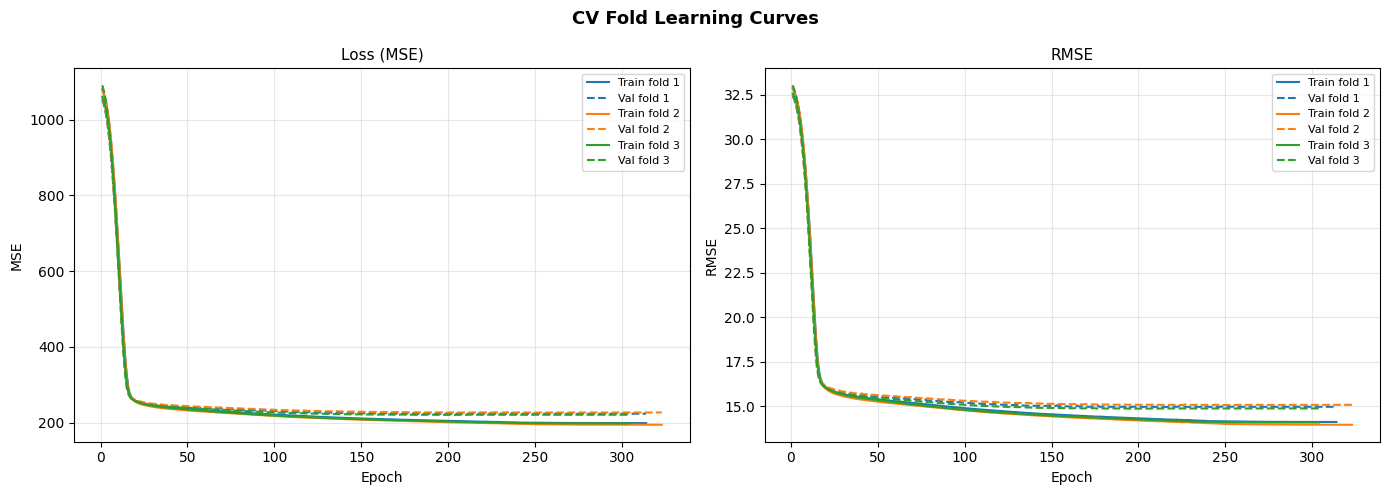

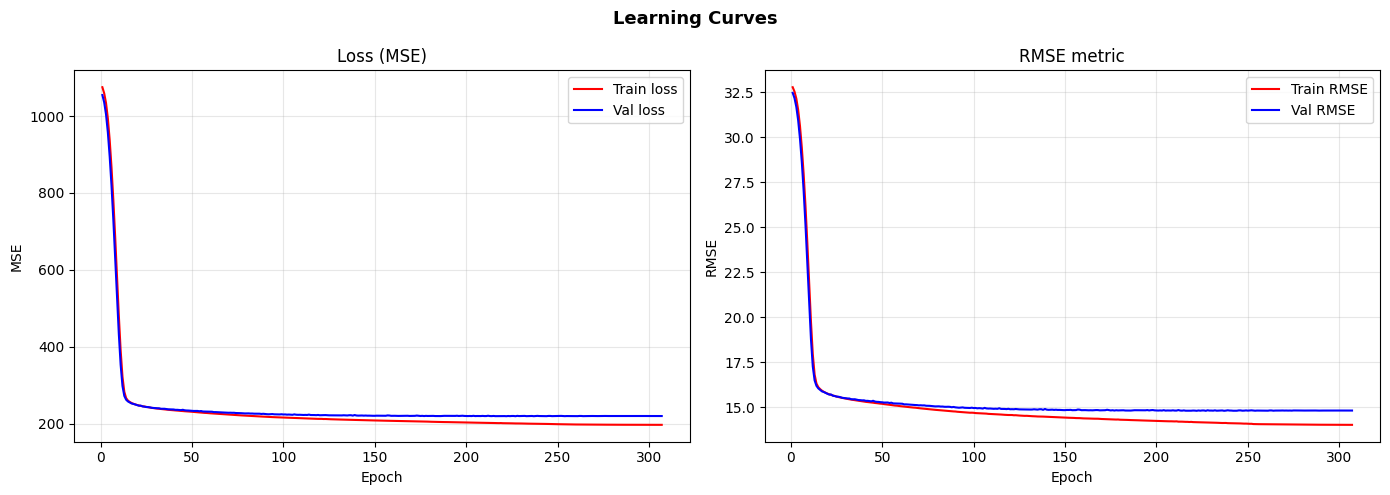

  Epochs run       : 307
  Final train loss : 197.2257
  Final val loss   : 220.1245
  Best  val loss   : 219.6617  (epoch 227)


In [11]:

FOLD_LC_FILE = f"fold_histories_pxpy.parquet"
LC_FILE    = f"learning_curves_pxpy.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Fold learning curves
_plot_fold_learning_curves(df_folds)

# Learning curves
_plot_learning_curves(df_lc)

---

## DYJetsToLL

In [ ]:
EVENT      = "DYJetsToLL"
TEST_FILE = f"../TestingDatasets/testing_pxpy_{EVENT}.root"
PRED_FILE = f"predictions_testing_pxpy_{EVENT}.parquet"

# Reconstructed/Predicted MET vs GenMET
(pred_px, pred_py, pred_pt,
         true_px, true_py, true_pt,
         reco_px, reco_py, reco_pt) = load_predictions(EVENT)

# Scatterplots
_scatterplots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Performance metrics
_compute_metrics(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            label=EVENT,
        )

# Response plot
_response_plots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, max_scatter_points = 10000
        )

# Profile histogram response
_profile_histogram_response(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 50.0
        )

# rebuild X_test (scaled) for SHAP
_, data = _read_data(TEST_FILE)
X_test  = np.column_stack([data[f] for f in feature_names]).astype(np.float32)
X_test  = _apply_standardize(X_test, scaler["mean"], scaler["std"])

_feature_importance_shap(
    model         = model,
    X_test        = X_test,
    feature_names = feature_names,
    event         = EVENT,
)

FileNotFoundError: Parquet not found: predictions_testing_pxpy_DYJetsToLL.parquet

---

## HToAATo2Mu2B

In [ ]:
EVENT      = "HToAATo2Mu2B"
TEST_FILE = f"../TestingDatasets/testing_pxpy_{EVENT}.root"
PRED_FILE = f"predictions_testing_pxpy_{EVENT}.parquet"

# Reconstructed/Predicted MET vs GenMET
(pred_px, pred_py, pred_pt,
         true_px, true_py, true_pt,
         reco_px, reco_py, reco_pt) = load_predictions(EVENT)

# Scatterplots
_scatterplots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Performance metrics
_compute_metrics(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            label=EVENT,
        )

# Response plot
_response_plots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, max_scatter_points = 10000
        )

# Profile histogram response
_profile_histogram_response(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 50.0
        )

# rebuild X_test (scaled) for SHAP
_, data = _read_data(TEST_FILE)
X_test  = np.column_stack([data[f] for f in feature_names]).astype(np.float32)
X_test  = _apply_standardize(X_test, scaler["mean"], scaler["std"])

_feature_importance_shap(
    model         = model,
    X_test        = X_test,
    feature_names = feature_names,
    event         = EVENT,
)

---

## ZZTo2L2Nu

In [ ]:
EVENT      = "ZZTo2L2Nu"
TEST_FILE = f"../TestingDatasets/testing_pxpy_{EVENT}.root"
PRED_FILE = f"predictions_testing_pxpy_{EVENT}.parquet"

# Reconstructed/Predicted MET vs GenMET
(pred_px, pred_py, pred_pt,
         true_px, true_py, true_pt,
         reco_px, reco_py, reco_pt) = load_predictions(EVENT)

# Scatterplots
_scatterplots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT,
        )

# Performance metrics
_compute_metrics(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            label=EVENT,
        )

# Response plot
_response_plots(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, max_scatter_points = 10000
        )

# Profile histogram response
_profile_histogram_response(
            pred_px, pred_py, pred_pt,
            true_px, true_py, true_pt,
            reco_px, reco_py, reco_pt,
            event=EVENT, bin_width = 10.0,
            min_counts = 10, min_Gen = 50.0
        )

# rebuild X_test (scaled) for SHAP
_, data = _read_data(TEST_FILE)
X_test  = np.column_stack([data[f] for f in feature_names]).astype(np.float32)
X_test  = _apply_standardize(X_test, scaler["mean"], scaler["std"])

_feature_importance_shap(
    model         = model,
    X_test        = X_test,
    feature_names = feature_names,
    event         = EVENT,
)